In [50]:
from pathlib import Path
import sys, os

# Fix imports so src/ works
PROJECT_ROOT = Path.cwd().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DIR
print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from src.features import add_features

df = pd.read_csv(PROCESSED_DIR / "full_laptime_full.csv")  # or whatever your latest file is
df_fe = add_features(df)


PROJECT_ROOT: c:\Users\Josel\Dissertation\ML
PROCESSED_DIR: C:\Users\Josel\Dissertation\ML\data\processed


In [51]:
import pandas as pd
import pyarrow as pa

print("pandas", pd.__version__)
print("pyarrow", pa.__version__)


pandas 2.3.3
pyarrow 22.0.0


In [52]:
df = pd.read_csv(PROCESSED_DIR / "laps_multiyear_full.csv")
df.head()


,Year,Track,RaceId,Driver,Team,LapNumber,LapNumberNorm,LapTime_s,Stint,LapsSinceLastPit,StopsSoFar,Compound,TyreLife,Position,TrackStatus,is_pit_lap
0,2022,Bahrain,2022-Bahrain,VER,Red Bull Racing,1.0,0.017544,100.236,1.0,1,0.0,SOFT,4.0,2.0,1,0
1,2022,Bahrain,2022-Bahrain,VER,Red Bull Racing,2.0,0.035088,97.880,1.0,2,0.0,SOFT,5.0,2.0,1,0
2,2022,Bahrain,2022-Bahrain,VER,Red Bull Racing,3.0,0.052632,98.357,1.0,3,0.0,SOFT,6.0,2.0,1,0
3,2022,Bahrain,2022-Bahrain,VER,Red Bull Racing,4.0,0.070175,98.566,1.0,4,0.0,SOFT,7.0,2.0,1,0
4,2022,Bahrain,2022-Bahrain,VER,Red Bull Racing,5.0,0.087719,98.877,1.0,5,0.0,SOFT,8.0,2.0,1,0


In [53]:
df_fe = df.copy()

# Tyre age (fallback if TyreLife missing)
df_fe["TyreAge"] = df_fe["TyreLife"].fillna(df_fe["LapsSinceLastPit"])

# Lagged features per driver
df_fe = df_fe.sort_values(["RaceId", "Driver", "LapNumber"])

df_fe["LapTime_prev"] = df_fe.groupby(["RaceId", "Driver"])["LapNumber"].shift(1)
df_fe["TyreAge_prev"] = df_fe.groupby(["RaceId", "Driver"])["TyreAge"].shift(1)
df_fe["LapsSinceLastPit_prev"] = df_fe.groupby(["RaceId", "Driver"])["LapsSinceLastPit"].shift(1)

# Group by race, driver, stint
g_stint = df_fe.groupby(['RaceId', 'Driver', 'Stint'])

# Lap number within stint (1,2,3, ...)
df_fe['StintLap'] = g_stint.cumcount() + 1

# Total length of the stint (in laps)
stint_min = g_stint['LapNumber'].transform('min')
stint_max = g_stint['LapNumber'].transform('max')
df_fe['StintLength'] = stint_max - stint_min + 1

# Position within the stint (0–1)
df_fe['StintFrac'] = df_fe['StintLap'] / df_fe['StintLength']

# --- Tyre wear fraction ---

TYPICAL_LIFE = {"SOFT": 15, "MEDIUM": 25, "HARD": 35}
df_fe["TyreLifeExpected"] = df_fe["Compound"].map(TYPICAL_LIFE)
df_fe["TyreWearFrac"] = df_fe["TyreAge"] / df_fe["TyreLifeExpected"]
df_fe["TyreLife2"] = df_fe["TyreLife"] ** 2
df_fe["TyreLife_x_Compound"] = df_fe["TyreLife"].astype(int).astype(str) + "_" + df_fe["Compound"].astype(str)


# --- Laps remaining / race fraction ---

race_max_lap = df_fe.groupby("RaceId")["LapNumber"].transform("max")
df_fe["LapsRemaining"] = race_max_lap - df_fe["LapNumber"] + 1
df_fe["RaceFracRemaining"] = df_fe["LapsRemaining"] / race_max_lap

df_fe["lap_avg_3"] = (
    df_fe.groupby(["RaceId","Driver"])["LapTime_s"]
    .transform(lambda s: s.rolling(3, min_periods=1).mean())
)

df_fe["LapDelta"] = df_fe["LapTime_s"] - df_fe["lap_avg_3"]


# ---- How many cars pitted on each lap (per race) ----
pits_per_lap = (
    df_fe.groupby(["RaceId", "LapNumber"])["is_pit_lap"]
    .sum()
    .rename("CarsPittedThisLap")
)

df_fe = df_fe.merge(pits_per_lap, on=["RaceId", "LapNumber"], how="left")
df_fe["CarsPittedThisLap"] = df_fe["CarsPittedThisLap"].fillna(0)

# Cars that pitted on the previous lap and in last 3 laps
df_fe["CarsPittedPrevLap"] = (
    df_fe.groupby("RaceId")["CarsPittedThisLap"].shift(1).fillna(0)
)

df_fe["CarsPittedLast3"] = (
    df_fe.groupby("RaceId")["CarsPittedThisLap"]
    .rolling(3)
    .sum()
    .reset_index(level=0, drop=True)
    .fillna(0)
)

# ---- Position change features (per driver & race) ----
g_drv = df_fe.groupby(["RaceId", "Driver"])

df_fe["Pos_prev"] = g_drv["Position"].shift(1)
df_fe["PosChange1"] = (df_fe["Pos_prev"] - df_fe["Position"]).fillna(0)

# change over last 3 laps
df_fe["PosChange3"] = (
    g_drv["Position"].diff(3).fillna(0)
)

# ---- Safety car / VSC features ----
df_fe["TrackStatus"] = df_fe["TrackStatus"].astype(str)

df_fe["IsSC"] = df_fe["TrackStatus"].str.contains("4|5").astype(int)
df_fe["IsVSC"] = df_fe["TrackStatus"].str.contains("6").astype(int)

# Boolean feature: tyre is old
df_fe["IsOldTyre"] = (df_fe["TyreAge"] > 12).astype(int)

df_fe["IsPitLap"] = df_fe["is_pit_lap"].astype(int)
df_fe["IsOutLap"] = df_fe.groupby(["RaceId","Driver"])["is_pit_lap"].shift(1).fillna(0).astype(int)

df_fe["WearSquared"] = df_fe["TyreWearFrac"] ** 2
df_fe["Wear_x_StintFrac"] = df_fe["TyreWearFrac"] * df_fe["StintFrac"]


df_fe.head()


,Year,Track,RaceId,Driver,Team,LapNumber,LapNumberNorm,LapTime_s,Stint,LapsSinceLastPit,...,Pos_prev,PosChange1,PosChange3,IsSC,IsVSC,IsOldTyre,IsPitLap,IsOutLap,WearSquared,Wear_x_StintFrac
0,2022,Abu Dhabi,2022-Abu Dhabi,ALB,Williams,1.0,0.017241,101.738,1.0,1,...,NaN,0.0,0.0,0,0,0,0,0,0.0016,0.003333
1,2022,Abu Dhabi,2022-Abu Dhabi,ALB,Williams,2.0,0.034483,93.227,1.0,2,...,17.0,1.0,0.0,0,0,0,0,0,0.0064,0.013333
2,2022,Abu Dhabi,2022-Abu Dhabi,ALB,Williams,3.0,0.051724,92.356,1.0,3,...,16.0,0.0,0.0,0,0,0,0,0,0.0144,0.030000
3,2022,Abu Dhabi,2022-Abu Dhabi,ALB,Williams,4.0,0.068966,93.137,1.0,4,...,16.0,0.0,-1.0,0,0,0,0,0,0.0256,0.053333
4,2022,Abu Dhabi,2022-Abu Dhabi,ALB,Williams,5.0,0.086207,92.652,1.0,5,...,16.0,1.0,-1.0,0,0,0,0,0,0.0400,0.083333


In [54]:
df_fe["pit_next_lap"] = (
    df_fe.groupby(["RaceId", "Driver"])["is_pit_lap"].shift(-1)
).fillna(0).astype(int)

def pit_within_window(x, w=3):
    out = []
    for i in range(len(x)):
        future = x[i+1:i+1+w]
        out.append(int(sum(future) > 0)) 
    return out

df_fe["pit_within_3"] = (
    df_fe.groupby(["RaceId", "Driver"])["is_pit_lap"]
    .transform(lambda s: pit_within_window(list(s), w=3))
)



In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import TRAIN_RACES, TEST_RACES

# -----------------------------
# 0) Ensure df_fe is sorted
# -----------------------------
df_fe = df_fe.sort_values(["RaceId", "Driver", "LapNumber"]).copy()

# -----------------------------
# 1) Ensure TyreWearFrac exists (BEFORE split)
# -----------------------------
if "TyreWearFrac" not in df_fe.columns:
    WEAR_CAP = {"SOFT": 18, "MEDIUM": 25, "HARD": 35}
    cap = df_fe["Compound"].astype(str).str.upper().map(WEAR_CAP).fillna(25).astype(float)
    df_fe["TyreWearFrac"] = (df_fe["TyreLife"].astype(float) / cap).clip(0, 1)

# -----------------------------
# 2) Build lap_avg_3 and LapDelta (BEFORE split)
df_fe["LapTime_s"] = pd.to_numeric(df_fe["LapTime_s"], errors="coerce")

# -----------------------------
df_fe = df_fe.sort_values(["RaceId","Driver","LapNumber"]).copy()

df_fe["lap_avg_3"] = (
    df_fe.groupby(["RaceId","Driver"])["LapTime_s"]
    .transform(lambda s: s.rolling(3, min_periods=1).mean())
)

df_fe["LapDelta"] = (df_fe["LapTime_s"] - df_fe["lap_avg_3"]).fillna(0.0)



# -----------------------------
# 3) PIT window model features
# -----------------------------
target_pit = "pit_within_3"

categorical_pit = ["Compound", "Team", "TyreLife_x_Compound"]

numeric_pit = [
    "LapsSinceLastPit",
    "TyreAge",
    "TyreWearFrac",
    "lap_avg_3",
    "IsOldTyre",
    "LapNumberNorm",
    "StintLap",
    "StintLength",
    "StintFrac",
    "LapsRemaining",
    "RaceFracRemaining",
    "CarsPittedPrevLap",
    "CarsPittedLast3",
    "PosChange1",
    "PosChange3",
    "IsSC",
    "IsVSC",
    "TyreLife2",
    #"IsPitLap",
    #"IsOutLap",
]

features_pit = numeric_pit + categorical_pit

# -----------------------------
# 4) PACE model features
# -----------------------------
# IMPORTANT: pace target should be LapDelta (not raw LapTime_s) if you want degradation dynamics
target_pace = "LapDelta"

categorical_pace = ["Compound", "Team", "TrackStatus"]

numeric_pace = [
    "LapNumberNorm",
    "LapsSinceLastPit",
    "TyreLife",
    "TyreWearFrac",
    "Stint",
    "StopsSoFar",
    "Position",
    "lap_avg_3",
    "IsSC",
    "IsVSC",
]

features_pace = numeric_pace + categorical_pace

# -----------------------------
# 5) Train/test split (AFTER features exist)
# -----------------------------
train_ids = {f"{year}-{race}" for (year, race) in TRAIN_RACES}
test_ids  = {f"{year}-{race}" for (year, race) in TEST_RACES}

train_df = df_fe[df_fe["RaceId"].isin(train_ids)].copy()
test_df  = df_fe[df_fe["RaceId"].isin(test_ids)].copy()

# PIT splits
X_train_pit = train_df[features_pit]
y_train_pit = train_df[target_pit]
X_test_pit  = test_df[features_pit]
y_test_pit  = test_df[target_pit]

# PACE splits
X_train_pace = train_df[features_pace]
y_train_pace = train_df[target_pace]
X_test_pace  = test_df[features_pace]
y_test_pace  = test_df[target_pace]

print("PIT:", X_train_pit.shape, X_test_pit.shape)
print("PACE:", X_train_pace.shape, X_test_pace.shape)

# Quick sanity checks
print("Has TyreWearFrac?", "TyreWearFrac" in df_fe.columns)
print("Has LapDelta?", "LapDelta" in df_fe.columns)
print(df_fe[["Compound","TyreLife","TyreWearFrac","LapTime_s","lap_avg_3","LapDelta"]].head(5))
print(df_fe[["LapTime_s","lap_avg_3","LapDelta"]].head(10))
print(df_fe[["LapTime_s","lap_avg_3","LapDelta"]].describe())



PIT: (90919, 21) (4191, 21)
PACE: (90919, 13) (4191, 13)
Has TyreWearFrac? True
Has LapDelta? True
  Compound  TyreLife  TyreWearFrac  LapTime_s   lap_avg_3  LapDelta
0   MEDIUM       1.0          0.04    101.738  101.738000  0.000000
1   MEDIUM       2.0          0.08     93.227   97.482500 -4.255500
2   MEDIUM       3.0          0.12     92.356   95.773667 -3.417667
3   MEDIUM       4.0          0.16     93.137   92.906667  0.230333
4   MEDIUM       5.0          0.20     92.652   92.715000 -0.063000
   LapTime_s   lap_avg_3  LapDelta
0    101.738  101.738000  0.000000
1     93.227   97.482500 -4.255500
2     92.356   95.773667 -3.417667
3     93.137   92.906667  0.230333
4     92.652   92.715000 -0.063000
5     92.302   92.697000 -0.395000
6     91.987   92.313667 -0.326667
7     92.303   92.197333  0.105667
8     92.406   92.232000  0.174000
9     92.550   92.419667  0.130333
          LapTime_s     lap_avg_3      LapDelta
count  95110.000000  95110.000000  95110.000000
mean      91

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# 1) Remove crazy laps (pit in/out, red flag, errors)
df_fe = df_fe[df_fe["LapTime_s"].between(65, 140)].copy()

# 2) Optional: drop laps with missing critical fields
df_fe = df_fe.dropna(subset=["Compound", "Team", "TyreLife", "LapsSinceLastPit", "LapNumber"])

# Numeric preprocessing
numeric_transformer_pit = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing (dense output)
categorical_transformer_pit = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

pre_pit = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_pit, numeric_pit),
        ("cat", categorical_transformer_pit, categorical_pit),
    ],
    remainder="drop",
)
for c in categorical_pit:
    print(c, "unique:", df_fe[c].nunique())



Compound unique: 5
Team unique: 13
TyreLife_x_Compound unique: 270


In [57]:
from pathlib import Path

# notebook is in Dissertation/ML/notebooks/...
THIS_FILE_DIR = Path.cwd()

# go up one to Dissertation/ML
ML_ROOT = THIS_FILE_DIR.parent

out_dir = ML_ROOT / "data"
out_dir.mkdir(parents=True, exist_ok=True)

df_fe.to_parquet(out_dir / "df_fe.parquet", index=False)
print("Saved to:", (out_dir / "df_fe.parquet").resolve())


Saved to: C:\Users\Josel\Dissertation\ML\data\df_fe.parquet


In [58]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler


def make_preprocessor(feature_list):
    categorical = [c for c in ["Compound", "Team", "TyreLife_x_Compound", "TrackStatus"] if c in feature_list]
    numeric = [f for f in feature_list if f not in categorical]

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric),
            ("cat", categorical_transformer, categorical),
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )
    return pre, numeric, categorical
pre_pit, pit_num, pit_cat = make_preprocessor(features_pit)
pre_pace, pace_num, pace_cat = make_preprocessor(features_pace)



Trained pace_model: HistGradientBoostingRegressor(learning_rate=0.08, max_depth=6, max_iter=400,
                              random_state=42)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3836
           1       0.99      0.96      0.98       355

    accuracy                           1.00      4191
   macro avg       1.00      0.98      0.99      4191
weighted avg       1.00      1.00      1.00      4191

[[3834    2]
 [  14  341]]
ROC-AUC: 0.9982067588009811
Rows in stint subset: 24 compound: HARD stint: 2.0


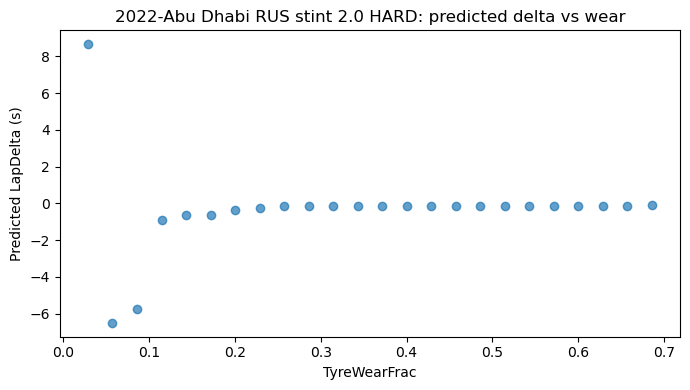

Corr within stint: 0.08415377389095353


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier

pit_classifier = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.08,
    max_iter=300,
    random_state=42
)

pit_model = Pipeline([
    ("preprocess", pre_pit),   # keep your preprocessor
    ("model", pit_classifier)
])

pit_model.fit(X_train_pit, y_train_pit)

pred = pit_model.predict(X_test_pit)
proba = pit_model.predict_proba(X_test_pit)[:, 1]

pace_model = Pipeline([
    ("preprocess", pre_pace),
    ("model", HistGradientBoostingRegressor(
        max_depth=6,
        learning_rate=0.08,
        max_iter=400,
        random_state=42
    ))
])

pace_model.fit(X_train_pace, y_train_pace)

print("Trained pace_model:", pace_model.named_steps["model"])
print(classification_report(y_test_pit, pred))
print(confusion_matrix(y_test_pit, pred))
print("ROC-AUC:", roc_auc_score(y_test_pit, proba))

race_id = "2022-Abu Dhabi"
driver = "RUS"

sub = df_fe[(df_fe["RaceId"] == race_id) & (df_fe["Driver"] == driver)].copy()
sub = sub.sort_values("LapNumber")

# choose a mid-race stint with enough laps (exclude pit/out laps if you have flags)
stint_id = sub["Stint"].mode().iloc[0]  # or manually set e.g. 2
st = sub[sub["Stint"] == stint_id].copy()

# optionally: keep a single compound to avoid compound switching effects
compound = st["Compound"].mode().iloc[0]
st = st[st["Compound"] == compound].copy()

print("Rows in stint subset:", len(st), "compound:", compound, "stint:", stint_id)


X_st = st[features_pace]
st["pred_delta"] = pace_model.predict(X_st)

import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.scatter(st["TyreWearFrac"], st["pred_delta"], alpha=0.7)
plt.xlabel("TyreWearFrac")
plt.ylabel("Predicted LapDelta (s)")
plt.title(f"{race_id} {driver} stint {stint_id} {compound}: predicted delta vs wear")
plt.tight_layout()
plt.show()

print("Corr within stint:", st["TyreWearFrac"].corr(st["pred_delta"]))



In [60]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.inspection import permutation_importance

# ------------------------------------------------------------
# 0) Sanity checks: make sure your variables are correct
# ------------------------------------------------------------
print("pace_model model:", pace_model.named_steps["model"])
print("pit_model model:", pit_model.named_steps["model"])   # <-- you must have this
print("Have pace splits:", "X_test_pace" in globals(), "y_test_pace" in globals())
print("Have pit splits:", "X_test_pit" in globals(), "y_test_pit" in globals())
print("Have test_df:", "test_df" in globals())
print("Have features_pit:", "features_pit" in globals(), "target_pit:", "target_pit" in globals())


# ------------------------------------------------------------
# 1) PACE MODEL evaluation (regression)
#    y_test_pace must be LapTime_s
# ------------------------------------------------------------
y_pred_pace = pace_model.predict(X_test_pace)

mae = mean_absolute_error(y_test_pace, y_pred_pace)
rmse = np.sqrt(mean_squared_error(y_test_pace, y_pred_pace))

print("\nPACE MODEL:")
print("MAE (s):", mae)
print("RMSE (s):", rmse)

# ------------------------------------------------------------
# 2) PIT MODEL evaluation (classification)
#    y_test_pit must be pit_within_3
# ------------------------------------------------------------
pred_pit = pit_model.predict(X_test_pit)
proba_pit = pit_model.predict_proba(X_test_pit)[:, 1]

print("\nPIT MODEL:")
print(classification_report(y_test_pit, pred_pit))
print("Confusion matrix:\n", confusion_matrix(y_test_pit, pred_pit))
print("ROC-AUC:", roc_auc_score(y_test_pit, proba_pit))

# ------------------------------------------------------------
# 3) Local explainability (driver + race) using permutation importance
# ------------------------------------------------------------

race_id = "2022-Abu Dhabi"
driver_code = "RUS"

sub = test_df[(test_df["RaceId"] == race_id) & (test_df["Driver"] == driver_code)].copy()
print(f"Rows for {driver_code} in {race_id}:", len(sub))
if sub.empty:
    raise ValueError("No rows for this driver/race in test_df – check the names.")

X_sub = sub[features_pit]
y_sub = sub[target_pit]

r = permutation_importance(
    pit_model,          # ✅ must be pit_model
    X_sub,
    y_sub,
    n_repeats=15,
    random_state=42,
    n_jobs=-1
)

imp_df = (
    pd.DataFrame({
        "feature": features_pit,
        "importance_mean": r.importances_mean,
        "importance_std": r.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
)

print(imp_df.head(15))



print("y_test_pace head:", y_test_pace.head().tolist())
print("y_pred_pace head:", y_pred_pace[:5])
print("y_test_pace describe:\n", y_test_pace.describe())
print("pred describe:\n", pd.Series(y_pred_pace).describe())



pace_model model: HistGradientBoostingRegressor(learning_rate=0.08, max_depth=6, max_iter=400,
                              random_state=42)
pit_model model: HistGradientBoostingClassifier(learning_rate=0.08, max_depth=6, max_iter=300,
                               random_state=42)
Have pace splits: True True
Have pit splits: True True
Have test_df: True
Have features_pit: True target_pit: True

PACE MODEL:
MAE (s): 0.8749107775047545
RMSE (s): 2.1796501862641113

PIT MODEL:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3836
           1       0.99      0.96      0.98       355

    accuracy                           1.00      4191
   macro avg       1.00      0.98      0.99      4191
weighted avg       1.00      1.00      1.00      4191

Confusion matrix:
 [[3834    2]
 [  14  341]]
ROC-AUC: 0.9982067588009811
Rows for RUS in 2022-Abu Dhabi: 58
              feature  importance_mean  importance_std
8           StintFrac      

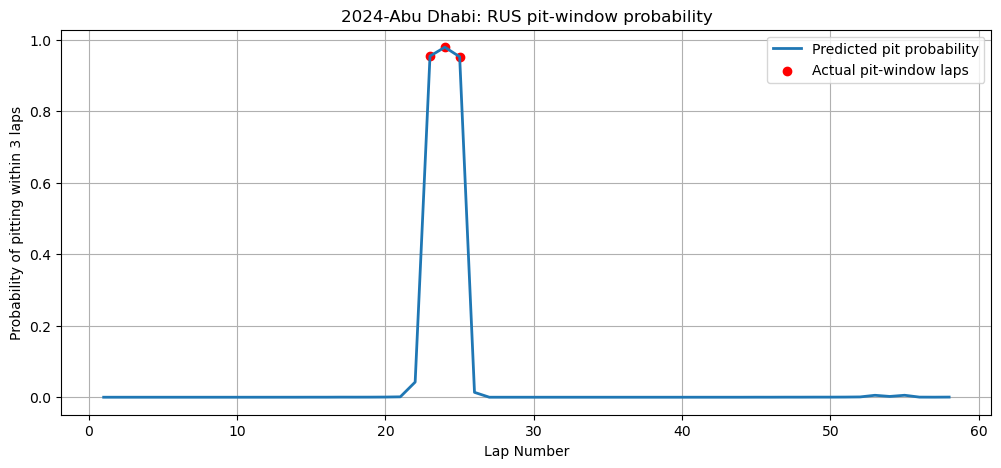

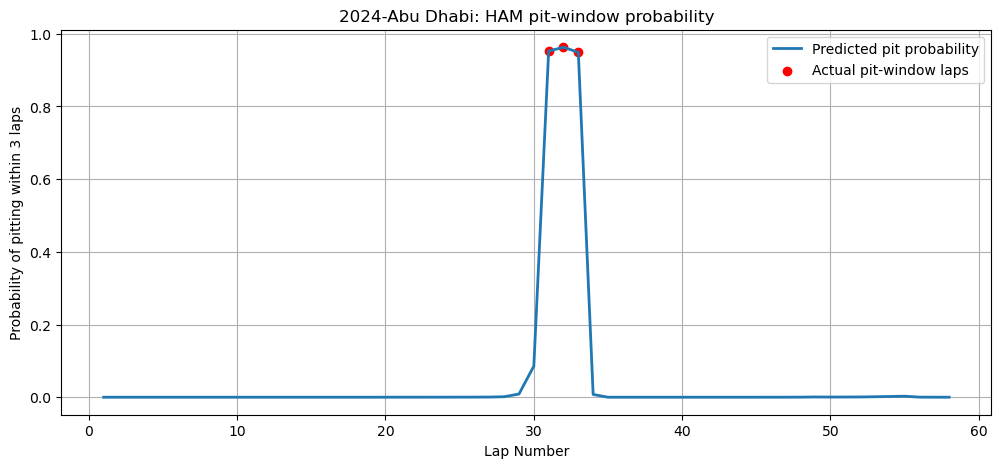

In [61]:

import matplotlib.pyplot as plt

def plot_driver_pit_probability(test_df, proba, driver_code, race_id, title=None):
    """
    Plot pit-window probability for a single driver in a single race.
    
    race_id should match the 'RaceId' column, e.g. '2023-Bahrain'.
    """
    df = test_df.copy()
    df = df.reset_index(drop=True)   # make sure indices match proba

    df["pit_proba"] = proba

    # Filter to this driver and race
    d = df[(df["Driver"] == driver_code) & (df["RaceId"] == race_id)].copy()
    d = d.sort_values("LapNumber")

    if d.empty:
        print(f"No data for driver {driver_code} in race {race_id} in the test set.")
        return

    if title is None:
        title = f"{race_id}: {driver_code} pit-window probability"

    plt.figure(figsize=(12,5))
    plt.plot(d["LapNumber"], d["pit_proba"], label="Predicted pit probability", linewidth=2)

    # Actual pit-window laps (where label == 1)
    if "pit_within_3" in d.columns:
        pw = d[d["pit_within_3"] == 1]
        plt.scatter(
            pw["LapNumber"],
            pw["pit_proba"],
            c="red",
            label="Actual pit-window laps"
        )

    plt.xlabel("Lap Number")
    plt.ylabel("Probability of pitting within 3 laps")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage:
plot_driver_pit_probability(test_df, proba, driver_code="RUS", race_id="2024-Abu Dhabi")
plot_driver_pit_probability(test_df, proba, driver_code="HAM", race_id="2024-Abu Dhabi")

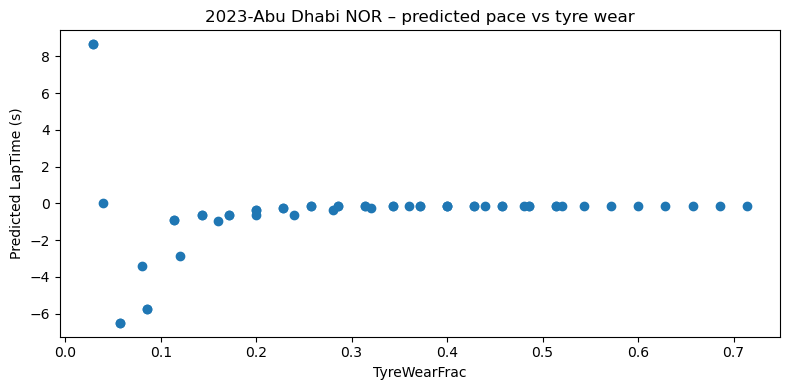

Correlation (TyreWearFrac vs predicted): 0.12479695609543247


In [62]:
import matplotlib.pyplot as plt
import numpy as np

race_id = "2023-Abu Dhabi"
driver = "NOR"

sub = df_fe[(df_fe["RaceId"] == race_id) & (df_fe["Driver"] == driver)].copy()
sub = sub.sort_values("LapNumber")

# remove pit / in-out laps if you have flags, otherwise approximate:
sub = sub[sub["is_pit_lap"] == 0].copy()

# predict
sub["pred_lap_time"] = pace_model.predict(sub[features_pace])

plt.figure(figsize=(8,4))
plt.scatter(sub["TyreWearFrac"], sub["pred_lap_time"])
plt.xlabel("TyreWearFrac")
plt.ylabel("Predicted LapTime (s)")
plt.title(f"{race_id} {driver} – predicted pace vs tyre wear")
plt.tight_layout()
plt.show()

print("Correlation (TyreWearFrac vs predicted):", sub["TyreWearFrac"].corr(sub["pred_lap_time"]))


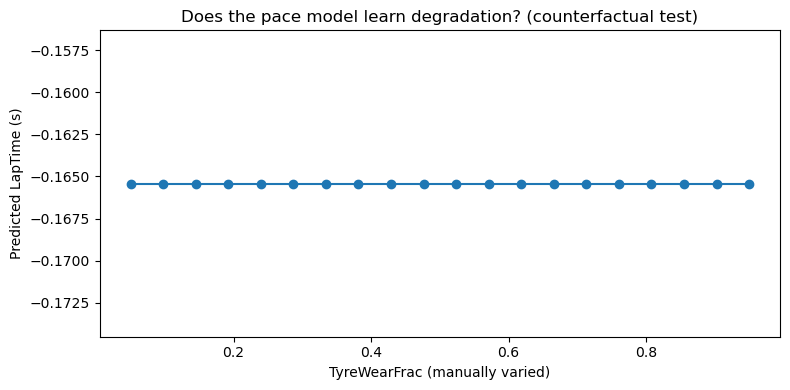

count    90919.000000
mean        -0.614253
std         19.814104
min      -1207.061000
25%         -0.298667
50%         -0.023333
75%          0.183667
max         43.120667
Name: LapDelta, dtype: float64
count    4191.000000
mean       -0.147915
std         3.711660
min       -26.742667
25%        -0.188167
50%        -0.010333
75%         0.157333
max        35.238333
Name: LapDelta, dtype: float64


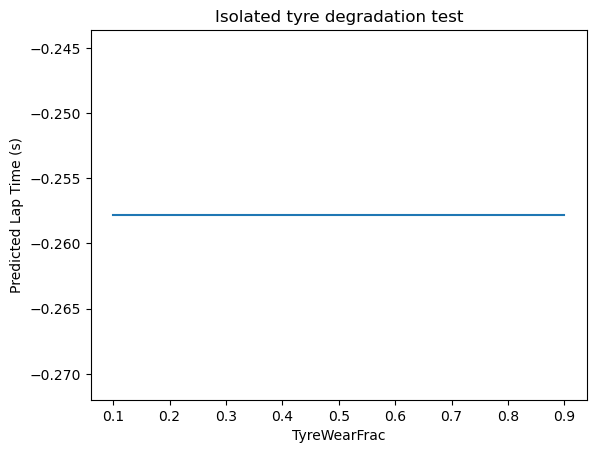

y_train describe:
count    90919.000000
mean        -0.614253
std         19.814104
min      -1207.061000
25%         -0.298667
50%         -0.023333
75%          0.183667
max         43.120667
Name: LapDelta, dtype: float64
Example LapTime_s values:
0    100.236
1     97.880
2     98.357
3     98.566
4     98.877
5     98.940
6     99.062
7     99.092
8     99.251
9     99.392
Name: LapTime_s, dtype: float64


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# choose a realistic base row
base = df_fe[(df_fe["RaceId"]=="2023-Abu Dhabi") & (df_fe["Driver"]=="NOR")].sort_values("LapNumber").iloc[10].copy()

grid = []
for w in np.linspace(0.05, 0.95, 20):
    r = base.copy()
    r["TyreWearFrac"] = w
    # keep TyreAge consistent if you have it
    # r["TyreAge"] = int(round(w * 30))
    grid.append(r)

grid_df = pd.DataFrame(grid)
pred = pace_model.predict(grid_df[features_pace])

plt.figure(figsize=(8,4))
plt.plot(grid_df["TyreWearFrac"], pred, marker="o")
plt.xlabel("TyreWearFrac (manually varied)")
plt.ylabel("Predicted LapTime (s)")
plt.title("Does the pace model learn degradation? (counterfactual test)")
plt.tight_layout()
plt.show()
print(y_train_pace.describe())
print(y_test_pace.describe())

row = sub.iloc[20].copy()  # any mid-stint lap

wears = np.linspace(0.1, 0.9, 20)
preds = []

for w in wears:
    r = row.copy()
    r["TyreWearFrac"] = w
    preds.append(pace_model.predict(pd.DataFrame([r]))[0])

import matplotlib.pyplot as plt
plt.plot(wears, preds)
plt.xlabel("TyreWearFrac")
plt.ylabel("Predicted Lap Time (s)")
plt.title("Isolated tyre degradation test")
plt.show()
print("y_train describe:")
print(y_train_pace.describe())

print("Example LapTime_s values:")
print(df["LapTime_s"].head(10))




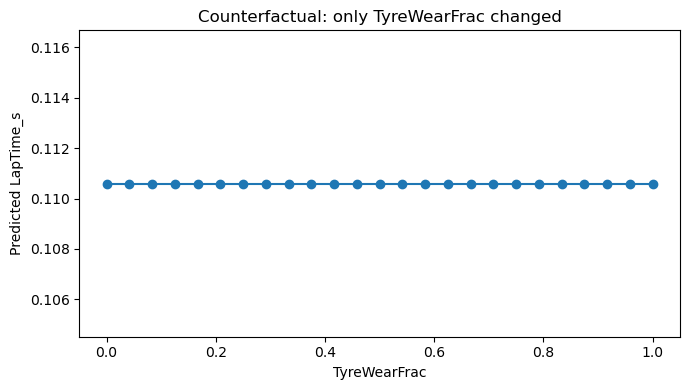

Pred min/max: 0.1105966373076229 0.1105966373076229 range: 0.0


In [64]:
import numpy as np
import matplotlib.pyplot as plt

# Pick a single example row from the *pace* test set
row = X_test_pace.iloc[[0]].copy()

# Ensure the column exists
assert "TyreWearFrac" in row.columns, "TyreWearFrac not in X_test_pace!"

vals = np.linspace(0.0, 1.0, 25)
preds = []

for v in vals:
    tmp = row.copy()
    tmp["TyreWearFrac"] = v
    preds.append(float(pace_model.predict(tmp)[0]))

plt.figure(figsize=(7,4))
plt.plot(vals, preds, marker="o")
plt.xlabel("TyreWearFrac")
plt.ylabel("Predicted LapTime_s")
plt.title("Counterfactual: only TyreWearFrac changed")
plt.tight_layout()
plt.show()

print("Pred min/max:", min(preds), max(preds), "range:", max(preds)-min(preds))


Corr(TyreWearFrac, predicted LapTime_s): 0.10785645717183563


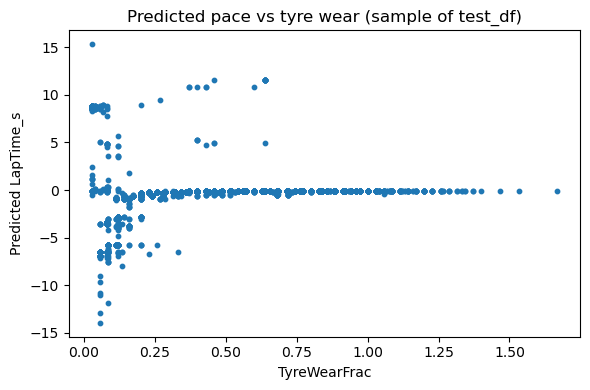

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sample a manageable number of laps (to keep it fast)
sample = test_df.sample(n=min(4000, len(test_df)), random_state=42).copy()

# Build X for pace features
X_s = sample[features_pace].copy()

pred_s = pace_model.predict(X_s)
sample["PredLapTime_s"] = pred_s

# Correlation (rough diagnostic)
corr = sample["TyreWearFrac"].corr(sample["PredLapTime_s"])
print("Corr(TyreWearFrac, predicted LapTime_s):", corr)

plt.figure(figsize=(6,4))
plt.scatter(sample["TyreWearFrac"], sample["PredLapTime_s"], s=10)
plt.xlabel("TyreWearFrac")
plt.ylabel("Predicted LapTime_s")
plt.title("Predicted pace vs tyre wear (sample of test_df)")
plt.tight_layout()
plt.show()
